In [2]:
import pandas as pd
import numpy as np
import wfdb
import ast
import sklearn

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

In [3]:
path = 'ptb-xl/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass

# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

### Fixing Y data for proper training format

In [4]:
mlb = MultiLabelBinarizer()
y_train_enc = mlb.fit_transform(y_train)
y_test_enc = mlb.fit_transform(y_test)
print("Encoded Labels (y_encoded):\n", y_train_enc)
print("\nClass Names (Order of Columns):\n", mlb.classes_)

Encoded Labels (y_encoded):
 [[0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 1 0]
 ...
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 0]]

Class Names (Order of Columns):
 ['CD' 'HYP' 'MI' 'NORM' 'STTC']


# Model Training

## Model structure

In [5]:
# THis is the number of classes. For Superclass it will be 5, if we do all of or a subset of the subclasses there can be more or less.
NUM_CLASSES = 5

# The input shape for the dataset
IN_SHAPE = (1000,12)

model = Sequential([
    Input(IN_SHAPE),
    Conv1D(filters=32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    # Dropout(0.5),
    Dense(NUM_CLASSES, activation='sigmoid')]
)

## Compiling and Fitting

In [6]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', # could also use categorical_crossentropy here for a single choice per input. Change output to softmax if doing that approach though
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True)]
)

In [7]:
model.fit(X_train, y_train_enc)

613/613 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.5824 - auc: 0.8327 - loss: 0.3917


## Testing

In [8]:
loss, accuracy, auc_score = model.evaluate(X_test, y_test_enc, verbose=1)

# Print the results
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc_score:.4f}")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6165 - auc: 0.8696 - loss: 0.3599
Test Loss: 0.3599
Test Accuracy: 0.6165
Test AUC: 0.8696


In [10]:
"""
IMPROVED CNN FOR ECG CLASSIFICATION
Optimized for PTB-XL dataset with better architecture and hyperparameters
"""

import tensorflow as tf
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, BatchNormalization, 
                                      Flatten, Dense, Dropout, Input, GlobalAveragePooling1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

def build_improved_cnn(input_shape, num_classes, l2_reg=0.001):
    """
    Improved CNN Architecture for ECG Classification
    
    Key improvements:
    1. Deeper architecture with residual-like connections
    2. Batch normalization for training stability
    3. Progressive filter increase
    4. Global average pooling instead of flatten
    5. L2 regularization
    6. Optimized dropout rates
    
    Parameters:
    input_shape : tuple - Shape of input ECG signal (time_steps, channels)
    num_classes : int - Number of diagnostic classes
    l2_reg : float - L2 regularization factor
    
    Returns: model : keras.Model - Compiled Keras model
    """
    inputs = Input(shape=input_shape)
    
    # Block 1: Initial feature extraction
    x = Conv1D(filters=64, kernel_size=7, strides=1, padding='same', 
               kernel_regularizer=l2(l2_reg))(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    
    # Block 2: Deeper feature learning
    x = Conv1D(filters=128, kernel_size=5, strides=1, padding='same',
               kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    # Block 3: Complex pattern recognition
    x = Conv1D(filters=256, kernel_size=3, strides=1, padding='same',
               kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    # Block 4: High-level features
    x = Conv1D(filters=256, kernel_size=3, strides=1, padding='same',
               kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Dropout(0.4)(x)
    
    # Global pooling - better than Flatten for variable-length sequences
    x = GlobalAveragePooling1D()(x)
    
    # Dense layers with decreasing size
    x = Dense(512, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = Dense(256, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Improved_CNN')
    
    return model

In [ ]:
def get_optimized_callbacks(patience_early=15, patience_lr=5, min_lr=1e-7):
    """
    Get optimized callbacks for training
    
    Parameters:
    patience_early : int - Patience for early stopping
    patience_lr : int - Patience for learning rate reduction
    min_lr : float - Minimum learning rate
    
    Returns:   callbacks : list - List of Keras callbacks
    """
    
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience_early,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=patience_lr,
        min_lr=min_lr,
        verbose=1
    )
    
    checkpoint = ModelCheckpoint(
        'best_improved_cnn.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    
    return [early_stopping, reduce_lr, checkpoint]

In [12]:
def compile_improved_cnn(model, learning_rate=0.001):
    """
    Compile model with optimized settings
    
    Parameters:
    
    model : keras.Model -   Model to compile
    learning_rate : float -  Initial learning rate
    
    Returns:
    model : keras.Model  -   Compiled model
    """
    
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

In [13]:
# COMPLETE TRAINING PIPELINE
def train_improved_cnn(X_train, y_train, X_val, y_val, 
                       batch_size=32, epochs=100, learning_rate=0.001):
    """
    Complete training pipeline for improved CNN
    
    Parameters:
    X_train : np.array - Training ECG signals
    y_train : np.array - Training labels (binary encoded)
    X_val : np.array -  Validation ECG signals
    y_val : np.array -  Validation labels
    batch_size : int -   Batch size for training
    epochs : int -  Maximum number of epochs
    learning_rate : float -   Initial learning rate
    
    Returns:
    model : keras.Model - Trained model
    history : keras.History - Training history
    """
    
    print("=" * 70)
    print("BUILDING IMPROVED CNN")
    print("=" * 70)
    
    # Build model
    input_shape = X_train.shape[1:]
    num_classes = y_train.shape[1]
    
    model = build_improved_cnn(input_shape, num_classes)
    model = compile_improved_cnn(model, learning_rate)
    
    # Print architecture
    print("\nModel Architecture:")
    model.summary()
    
    print("\n" + "=" * 70)
    print("TRAINING IMPROVED CNN")
    print("=" * 70)
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Batch size: {batch_size}")
    print(f"Initial learning rate: {learning_rate}")
    print(f"Max epochs: {epochs}")
    
    # Get callbacks
    callbacks = get_optimized_callbacks()
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    print("\n" + "=" * 70)
    print("TRAINING COMPLETE")
    print("=" * 70)
    
    return model, history

In [14]:
# ALTERNATIVE: Even More Aggressive Architecture
def build_deep_cnn(input_shape, num_classes):
    """
    Deeper CNN with more capacity
    Use this if you have more training data or need better performance
    """
    
    inputs = Input(shape=input_shape)
    
    # Initial Conv Block
    x = Conv1D(64, 7, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Dropout(0.2)(x)
    
    # 5 Convolutional Blocks
    filters = [128, 256, 384, 512, 512]
    kernel_sizes = [7, 5, 5, 3, 3]
    
    for f, k in zip(filters, kernel_sizes):
        x = Conv1D(f, k, padding='same')(x)
        x = BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        x = MaxPooling1D(2)(x)
        x = Dropout(0.3)(x)
    
    # Global pooling and dense layers
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Deep_CNN')
    return model

In [16]:
# BUILD AND COMPILE THE MODEL

# Get dimensions from your data
input_shape = (X_train.shape[1], X_train.shape[2])  # Should be (1000, 12)
num_classes = y_train_enc.shape[1]  # Should be 5

print(f"Input shape: {input_shape}")
print(f"Number of classes: {num_classes}")

# Build the model
print("\nBuilding Deep CNN...")
model = build_deep_cnn(input_shape, num_classes)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Show the architecture
print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)
model.summary()

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal trainable parameters: {trainable_params:,}")

Input shape: (1000, 12)
Number of classes: 5

Building Deep CNN...

MODEL SUMMARY


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1000, 64)       │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1000, 128)      │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 500, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 500, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 250, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 250, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 250, 384)       │       491,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 250, 384)       │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 250, 384)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 125, 384)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 125, 384)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 125, 512)       │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,498,885 (9.53 MB)

 Trainable params: 2,495,173 (9.52 MB)

 Non-trainable params: 3,712 (14.50 KB)


Total trainable parameters: 2,495,173


In [17]:
# Define callbacks
callbacks = [
    # Stop training if validation loss doesn't improve for 15 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate if stuck on plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # Reduce LR by half
        patience=5,           # Wait 5 epochs before reducing
        min_lr=1e-7,
        verbose=1
    ),
    
    # Save the best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_deep_cnn.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("  Callbacks configured:")
print("  - Early Stopping (patience=15)")
print("  - Learning Rate Reduction (patience=5)")
print("  - Model Checkpoint (saves best model)")
print("\nReady to train!")

  Callbacks configured:
  - Early Stopping (patience=15)
  - Learning Rate Reduction (patience=5)
  - Model Checkpoint (saves best model)

Ready to train!


In [21]:
# Split training data into train and validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_enc, y_val_enc = train_test_split(
    X_train, y_train_enc, 
    test_size=0.15, 
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


# Train the model
history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed")

Training samples: 14161
Validation samples: 2499
Test samples: 2198
Epoch 1/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.4912 - auc: 0.7616 - loss: 0.4929 - precision: 0.5796 - recall: 0.3931
Epoch 1: val_loss improved from None to 0.40124, saving model to best_deep_cnn.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 233s 511ms/step - accuracy: 0.5517 - auc: 0.8225 - loss: 0.4365 - precision: 0.6598 - recall: 0.4768 - val_accuracy: 0.6359 - val_auc: 0.8609 - val_loss: 0.4012 - val_precision: 0.6912 - val_recall: 0.5739 - learning_rate: 0.0010
Epoch 2/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.6253 - auc: 0.8724 - loss: 0.3785 - precision: 0.7341 - recall: 0.5915
Epoch 2: val_loss improved from 0.40124 to 0.33831, saving model to best_deep_cnn.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 238s 536ms/step - accuracy: 0.6280 - auc: 0.8762 - loss: 0.3723 - precision: 0.7379 - recall: 0.5964 - val_accuracy: 0.6891 - val_auc: 0.8972 - val_loss: 0.3383 - val_precision: 0.7700 - val_

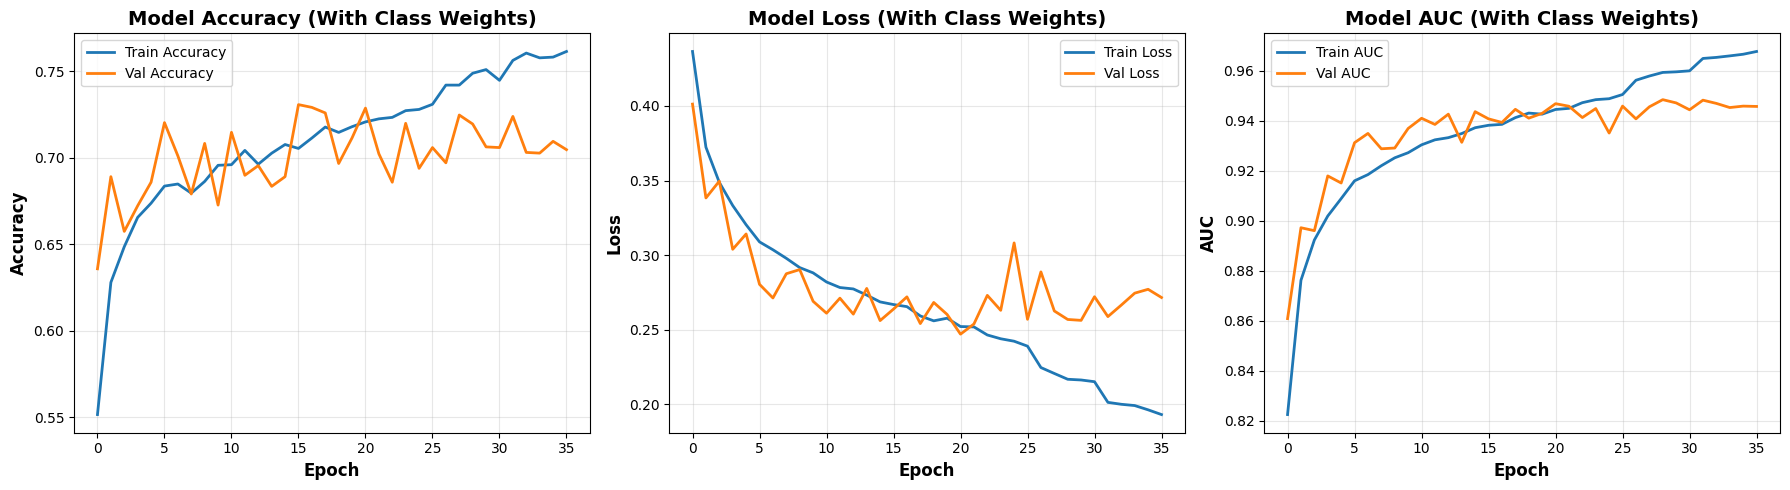

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Cell 1: Plot training history for the new model with class weights
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy (With Class Weights)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Loss (With Class Weights)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[2].set_ylabel('AUC', fontsize=12, fontweight='bold')
axes[2].set_title('Model AUC (With Class Weights)', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import ast
import wfdb
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf

print("="*70)
print("QUICK DATA LOADER - Loading test data only...")
print("="*70)

# Path to your PTB-XL dataset
path = 'ptb-xl/'

# Load metadata
print("\n1. Loading metadata...")
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load aggregation data for diagnostic classes
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# Define aggregation function
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
print("2. Applying diagnostic classes...")
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Get test fold data ONLY (fold 10)
test_fold = 10
test_df = Y[Y.strat_fold == test_fold]
print(f"   Test samples: {len(test_df)}")

# Load ONLY test ECG data (faster than loading all 21k records)
print("3. Loading test ECG signals... (this takes ~2-3 minutes)")
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

X_test = load_raw_data(test_df, 100, path)
y_test = test_df.diagnostic_superclass

print(f"    X_test shape: {X_test.shape}")

# Encode labels
print("4. Encoding labels...")
mlb = MultiLabelBinarizer()
# Fit with all possible classes to ensure consistent encoding
mlb.fit([['CD'], ['HYP'], ['MI'], ['NORM'], ['STTC']])
y_test_enc = mlb.transform(y_test)

print(f"    y_test_enc shape: {y_test_enc.shape}")
print(f"    Classes: {mlb.classes_}")

# Create dummy X_train and y_train_enc for compatibility (not needed for evaluation)
# Some cells might reference these, so we create minimal versions
X_train = np.zeros((1, 1000, 12))  # Dummy
y_train_enc = np.zeros((1, 5))     # Dummy
print("\n5. Created dummy training variables (not needed for evaluation)")

print("\n" + "="*70)
print(" Test data loaded and ready for evaluation")
print("="*70)
print(f"\nTest set ready:")
print(f"  - X_test: {X_test.shape} (2198 ECG signals, 1000 samples, 12 leads)")
print(f"  - y_test_enc: {y_test_enc.shape} (2198 labels, 5 classes)")
print(f"  - Classes: CD, HYP, MI, NORM, STTC")
print("="*70)

QUICK DATA LOADER - Loading test data only...

1. Loading metadata...
2. Applying diagnostic classes...
   Test samples: 2198
3. Loading test ECG signals... (this takes ~2-3 minutes)
    X_test shape: (2198, 1000, 12)
4. Encoding labels...
    y_test_enc shape: (2198, 5)
    Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']

5. Created dummy training variables (not needed for evaluation)

 Test data loaded and ready for evaluation

Test set ready:
  - X_test: (2198, 1000, 12) (2198 ECG signals, 1000 samples, 12 leads)
  - y_test_enc: (2198, 5) (2198 labels, 5 classes)
  - Classes: CD, HYP, MI, NORM, STTC


In [9]:
# STEP 1: Evaluate model

import tensorflow as tf

model_v2 = tf.keras.models.load_model('best_deep_cnn.keras')

test_loss, test_accuracy, test_auc, test_precision, test_recall = model_v2.evaluate(
    X_test, y_test_enc, verbose=0
)

accuracy_new = test_accuracy

print(f"Accuracy: {test_accuracy:.4f}")
print(f"AUC: {test_auc:.4f}")

Accuracy: 0.7052
AUC: 0.9329


In [10]:
 #STEP 2: Per-class metrics

y_pred_proba = model_v2.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

from sklearn.metrics import classification_report

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
print(classification_report(y_test_enc, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

          CD     0.8089    0.6573    0.7253       496
         HYP     0.7207    0.4924    0.5850       262
          MI     0.7969    0.6491    0.7154       550
        NORM     0.8155    0.9086    0.8595       963
        STTC     0.7680    0.7370    0.7522       521

   micro avg     0.7956    0.7418    0.7677      2792
   macro avg     0.7820    0.6889    0.7275      2792
weighted avg     0.7929    0.7418    0.7615      2792
 samples avg     0.7796    0.7539    0.7522      2792



c:\Users\dxkcad1\Desktop\ECGClassificationPreturbation\ECG_Classification_Perturbation\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dxkcad1\Desktop\ECGClassificationPreturbation\ECG_Classification_Perturbation\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dxkcad1\Desktop\ECGClassificationPreturbation\ECG_Classification_Perturbation\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in s

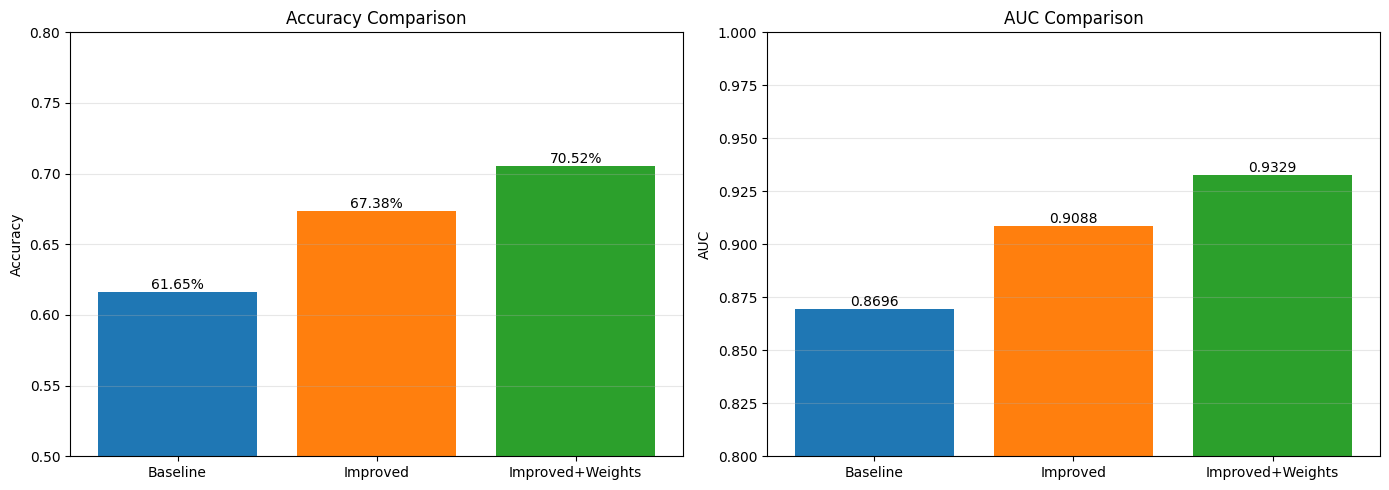

Total accuracy improvement: +8.87%
Total AUC improvement: +0.0633


In [18]:
import matplotlib.pyplot as plt

model_names = ['Baseline', 'Improved', 'Improved+Weights']
accuracies = [0.6165, 0.6738, accuracy_new]
aucs = [0.8696, 0.9088, test_auc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(model_names, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim([0.5, 0.8])
axes[0].grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom')

bars2 = axes[1].bar(model_names, aucs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC Comparison')
axes[1].set_ylim([0.8, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Total accuracy improvement: +{(accuracies[2]-accuracies[0])*100:.2f}%")
print(f"Total AUC improvement: +{(aucs[2]-aucs[0]):.4f}")

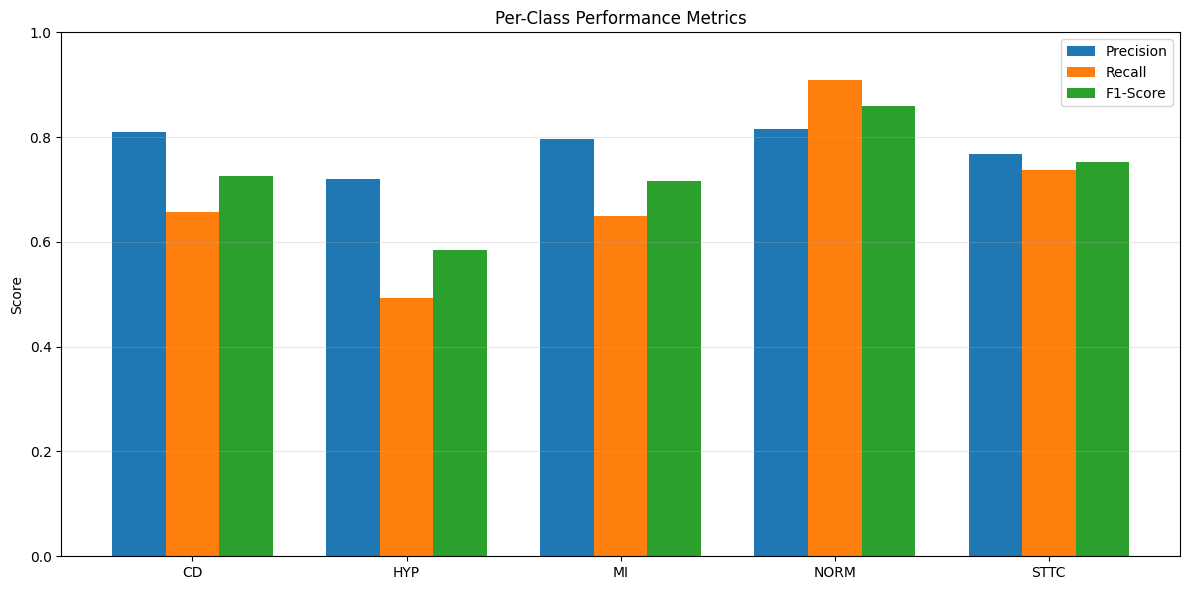

Per-Class Recall (most important for medical):
  CD: 0.6573
  HYP: 0.4924
  MI: 0.6491
  NORM: 0.9086
  STTC: 0.7370


In [19]:
# VISUALIZATION 1: Per-Class Performance Bars
# Shows which classes improved (especially HYP and CD)

from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

precision, recall, f1, support = precision_recall_fscore_support(y_test_enc, y_pred, average=None)
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
bars2 = ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#2ca02c')

ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

print("Per-Class Recall (most important for medical):")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {recall[i]:.4f}")

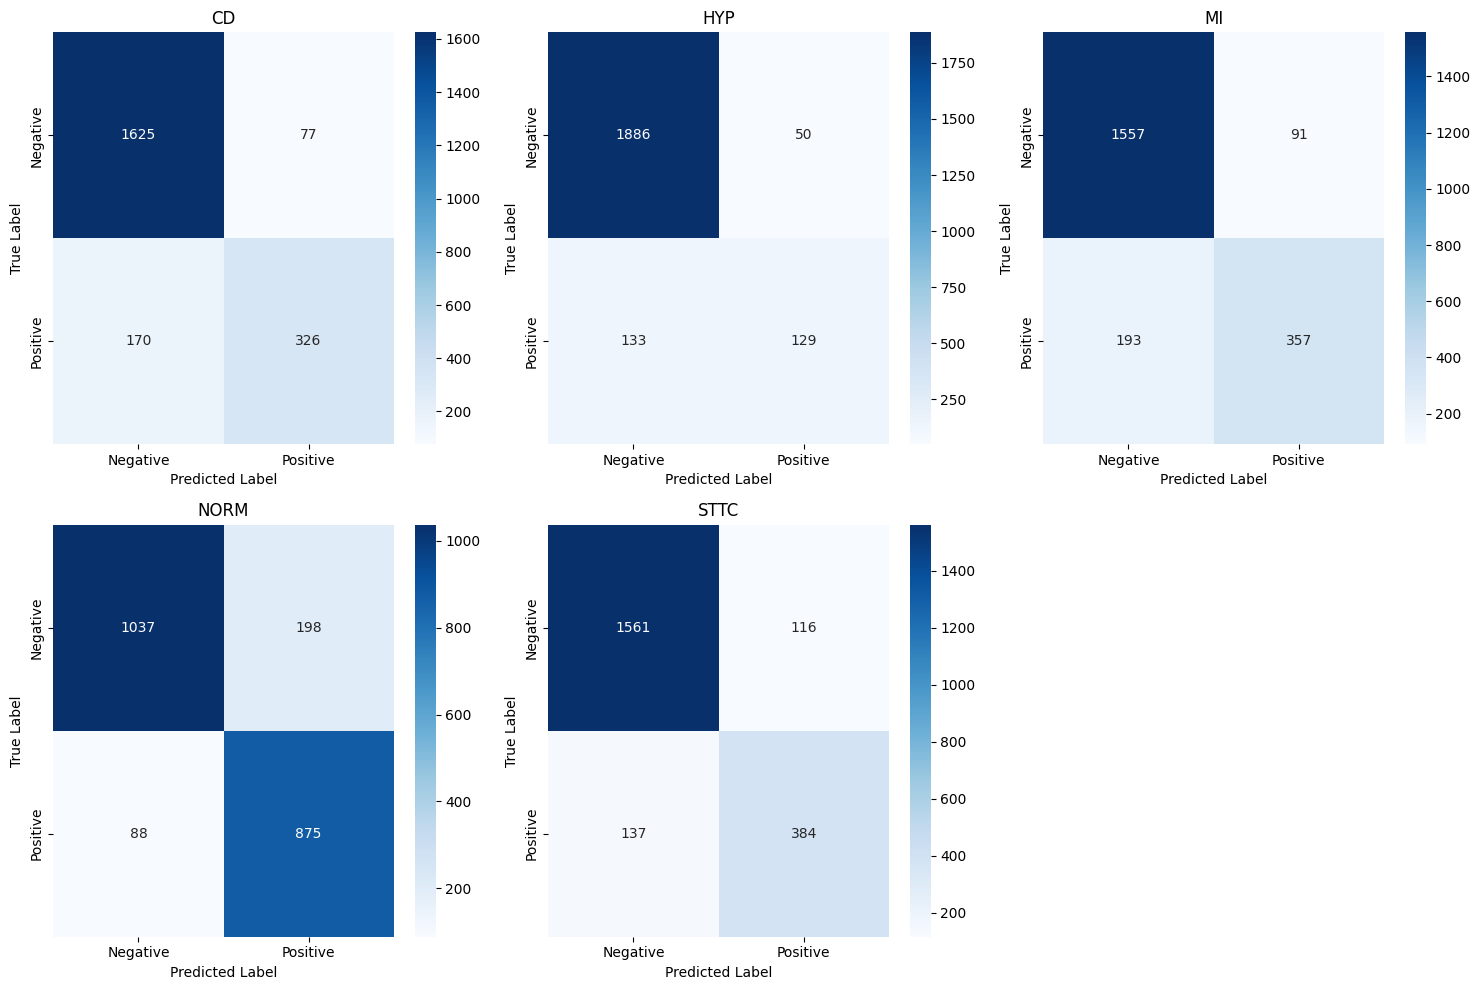

In [20]:
# VISUALIZATION 2: Confusion Matrices (one per class)
# Shows True Positives, False Positives, True Negatives, False Negatives

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_multilabel = multilabel_confusion_matrix(y_test_enc, y_pred)
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, class_name in enumerate(class_names):
    cm = cm_multilabel[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{class_name}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

axes[5].axis('off')
plt.tight_layout()
plt.show()

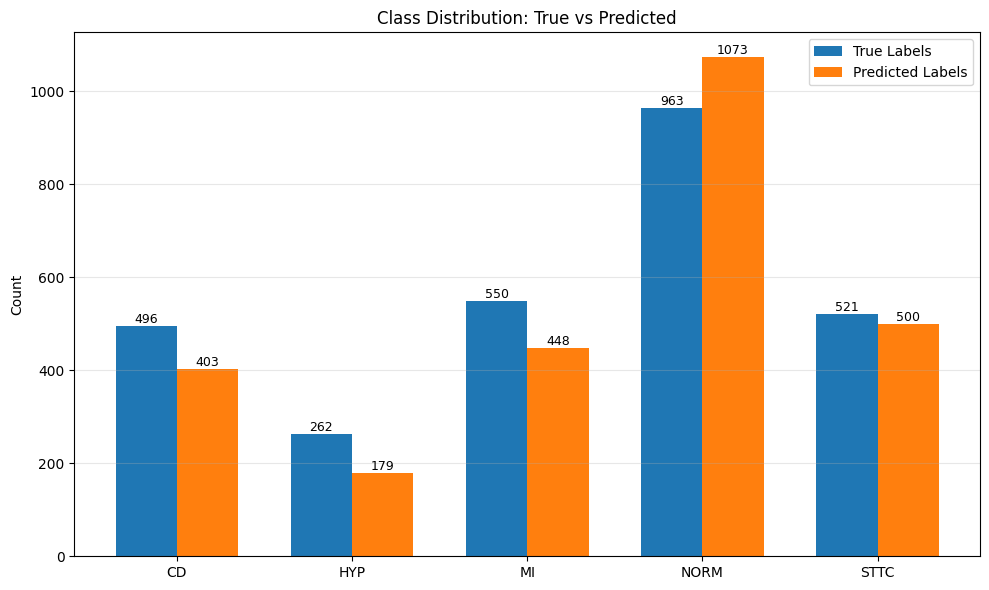


Class balance analysis:
CD: True=496, Predicted=403, Diff=-93
HYP: True=262, Predicted=179, Diff=-83
MI: True=550, Predicted=448, Diff=-102
NORM: True=963, Predicted=1073, Diff=110
STTC: True=521, Predicted=500, Diff=-21


In [21]:
# VISUALIZATION 3: Class Imbalance Before/After
# Shows how class weights helped balance predictions

import matplotlib.pyplot as plt
import numpy as np

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# True distribution
true_counts = y_test_enc.sum(axis=0)

# Predicted distribution
pred_counts = y_pred.sum(axis=0)

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, true_counts, width, label='True Labels', color='#1f77b4')
bars2 = ax.bar(x + width/2, pred_counts, width, label='Predicted Labels', color='#ff7f0e')

ax.set_ylabel('Count')
ax.set_title('Class Distribution: True vs Predicted')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nClass balance analysis:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: True={int(true_counts[i])}, Predicted={int(pred_counts[i])}, Diff={int(pred_counts[i]-true_counts[i])}")